Data Cleaning and Exploration
Indicated damage is the class label we want to predict

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
train_data = pd.read_csv('train.csv', header='infer')
test_data = pd.read_csv('test.csv', header='infer')
print("Number of rows and columns in training data: ", train_data.shape)
train_data.head()
train_data.info()

/var/folders/j1/9v5pdr3x0yq9w6b8wmphvp2c0000gn/T/ipykernel_49249/15802462.py:1: DtypeWarning: Columns (8,9,20) have mixed types. Specify dtype option on import or set low_memory=False.
  train_data = pd.read_csv('train.csv', header='infer')
/var/folders/j1/9v5pdr3x0yq9w6b8wmphvp2c0000gn/T/ipykernel_49249/15802462.py:2: DtypeWarning: Columns (8,9,20,37) have mixed types. Specify dtype option on import or set low_memory=False.
  test_data = pd.read_csv('test.csv', header='infer')


Number of rows and columns in training data:  (307178, 55)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307178 entries, 0 to 307177
Data columns (total 55 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   INDEX_NR              307178 non-null  int64  
 1   INCIDENT_DATE         307178 non-null  object 
 2   INCIDENT_MONTH        307178 non-null  int64  
 3   INCIDENT_YEAR         307178 non-null  int64  
 4   TIME                  197926 non-null  object 
 5   TIME_OF_DAY           173207 non-null  object 
 6   AIRPORT_ID            307178 non-null  object 
 7   AIRPORT               307178 non-null  object 
 8   LATITUDE              266434 non-null  object 
 9   LONGITUDE             266431 non-null  object 
 10  RUNWAY                231593 non-null  object 
 11  STATE                 266434 non-null  object 
 12  FAAREGION             266434 non-null  object 
 13  LOCATION              39218 non-null   object

In [3]:
train_data.describe()

,INDEX_NR,INCIDENT_MONTH,INCIDENT_YEAR,EMA,EMO,AC_MASS,NUM_ENGS,ENG_1_POS,ENG_2_POS,ENG_3_POS,ENG_4_POS,HEIGHT,SPEED,DISTANCE,OUT_OF_RANGE_SPECIES,REMAINS_COLLECTED,REMAINS_SENT,TRANSFER,INDICATED_DAMAGE
count,3.071780e+05,307178.000000,307178.000000,204757.000000,194002.00000,219732.000000,219481.000000,219461.000000,204669.000000,12356.000000,3269.000000,152981.000000,95102.000000,203875.000000,307178.000000,307178.000000,307178.000000,307178.0,307178.000000
mean,1.030746e+06,7.221136,2013.629697,19.308815,8.15889,3.557770,2.004328,2.722128,2.546287,2.909922,2.162435,882.259627,142.973061,0.878159,0.000856,0.538925,0.179821,0.0,0.063569
std,3.851711e+05,2.750603,8.991125,10.573812,11.50024,0.865756,0.409663,2.117692,1.958387,1.938278,1.466136,1858.178379,46.550616,3.687059,0.029248,0.498483,0.384039,0.0,0.243984
min,6.082420e+05,1.000000,1990.000000,1.000000,0.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,7.054882e+05,5.000000,2008.000000,10.000000,1.00000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,0.000000,120.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
50%,8.052665e+05,8.000000,2015.000000,22.000000,4.00000,4.000000,2.000000,1.000000,1.000000,1.000000,1.000000,50.000000,140.000000,0.000000,0.000000,1.000000,0.000000,0.0,0.000000
75%,1.437907e+06,9.000000,2021.000000,31.000000,10.00000,4.000000,2.000000,5.000000,5.000000,5.000000,4.000000,1000.000000,160.000000,0.000000,0.000000,1.000000,0.000000,0.0,0.000000
max,1.825451e+06,12.000000,2026.000000,47.000000,97.00000,5.000000,4.000000,7.000000,7.000000,6.000000,5.000000,32000.000000,541.000000,99.000000,1.000000,1.000000,1.000000,0.0,1.000000


In [4]:
# Handling missing values
null_column_totals = train_data.isnull().sum().sort_values(ascending=False)
print("Number missing values for each column\n", null_column_totals)

Number missing values for each column
 BIRD_BAND_NUMBER        306465
ENG_4_POS               303909
ENROUTE_STATE           301832
PRECIPITATION           295966
ENG_3_POS               294822
LOCATION                267960
SPEED                   212076
NUM_SEEN                208546
SKY                     162825
FLT                     161435
HEIGHT                  154197
TIME_OF_DAY             133971
PHASE_OF_FLIGHT         120961
REG                     118982
AMO                     116813
EMO                     113176
TIME                    109252
DISTANCE                103303
COMMENTS                103083
ENG_2_POS               102509
EMA                     102421
AMA                      88896
TYPE_ENG                 87786
ENG_1_POS                87717
NUM_ENGS                 87697
AC_MASS                  87446
AC_CLASS                 87315
RUNWAY                   75585
LONGITUDE                40747
FAAREGION                40744
STATE                    40744


In [5]:
# remove any duplicates
print("Number of duplicate rows", train_data.duplicated().sum())
train_data.drop_duplicates()
# Shape of dataset remained the same, no duplicates found in training dataset

Number of duplicate rows 0


,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,LATITUDE,LONGITUDE,...,NUM_SEEN,NUM_STRUCK,SIZE,ENROUTE_STATE,COMMENTS,SOURCE,PERSON,LUPDATE,TRANSFER,INDICATED_DAMAGE
0,1410120,12/13/93,12,1993,NaN,Day,TJSJ,LUIS MUNOZ MARIN INTL,18.43942,-66.00183,...,10-Feb,10-Feb,Small,NaN,NaN,FAA Form 5200-7,Pilot,4/3/23,0,0
1,709688,2/1/10,2,2010,5:00,Night,WMKK,KUALA LUMPUR INTL,2.745578,101.709917,...,NaN,1,Medium,NaN,2010-5-18-53374 /Legacy Record 300758/,FAA Form 5200-7-E,Air Transport Operations,6/9/10,0,0
2,730841,5/9/12,5,2012,2:00,Night,KSDF,MUHAMMAD ALI INTERNATIONAL,38.17439,-85.736,...,NaN,1,Large,NaN,UPS EVENT REPT 36216 (4/22/13 UPDATED COST) /L...,Air Transport Report,Air Transport Operations,4/22/13,0,1
3,654676,10/8/02,10,2002,NaN,NaN,KLAX,LOS ANGELES INTL,33.94254,-118.40807,...,NaN,10-Feb,Medium,NaN,2002-10-8-111929 /Legacy Record 216397/,FAA Form 5200-7-E,Carcass Found,1/9/03,0,0
4,629708,2/3/97,2,1997,NaN,Dawn,PHLI,LIHUE ARPT,21.97598,-159.33896,...,1,1,Medium,NaN,SOURCE 5200-7 & PACIR /Legacy Record 121531/,Multiple,NaN,3/1/07,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307173,1786439,10/31/25,10,2025,,NaN,KVNC,VENICE MUNICIPAL AIRPORT,27.07161,-82.44033,...,NaN,1,Medium,NaN,NaN,FAA Form 5200-7-E,Carcass Found,1/2/26,0,0
307174,676049,8/20/06,8,2006,NaN,NaN,KORD,CHICAGO O'HARE INTL ARPT,41.9796,-87.90446,...,NaN,1,Small,NaN,2006-9-5-121657 /Legacy Record 237856/,FAA Form 5200-7-E,Carcass Found,11/16/06,0,0
307175,991735,5/31/19,5,2019,11:59,NaN,KTOA,ZAMPERINI FIELD ARPT,33.80338,-118.3396,...,NaN,1,Small,NaN,NaN,MOR,Tower,6/17/20,0,0
307176,1525457,6/22/20,6,2020,8:42,NaN,KDAL,DALLAS LOVE FIELD ARPT,32.84711,-96.85177,...,NaN,1,Small,NaN,NaN,FAA Form 5200-7-E,Carcass Found,5/20/24,0,0


In [6]:
# Drop columns that do not relate to prediction: remarks and comments
# Drop columns with less than 70% of row values filled
# BIRD_BAND_NUMBER        306465
# ENG_4_POS               303909
# ENROUTE_STATE           301832
# PRECIPITATION           295966
# ENG_3_POS               294822
# LOCATION                267961
# SPEED                   212076
# NUM_SEEN                208546
# WARNED                  191135
# SKY                     162825
# FLT                     161438
# HEIGHT                  154197
# TIME_OF_DAY             133971
# PHASE_OF_FLIGHT         120970
# REG                     118991
# AMO                     116813
# EMO                     113176
# TIME                    109252
# DISTANCE                103303
# COMMENTS                103083
# ENG_2_POS               102509
# EMA                     102421
print(train_data.shape)
# Drop columns with less than 70% of rows filled
# train_data = train_data.drop(columns=["BIRD_BAND_NUMBER", "ENG_4_POS", "ENG_3_POS", "LOCATION", "SPEED", "NUM_SEEN", "WARNED", "SKY", "FLT", "HEIGHT", "TIME_OF_DAY", "PHASE_OF_FLIGHT", "REG", "AMO", "EMO", "TIME", "DISTANCE", "ENG_2_POS", "EMA", "AMA"])
train_data = train_data.drop(columns=["FLT", "REG", "AMO", "EMO", "TIME", "EMA", "AMA"])
print(train_data.shape)


# Drop Airports since AIRPORT is just name corresponding to AIRPORT_ID (reduce dimensionality)
train_data = train_data.drop(columns=["AIRPORT"])
# Drop LOCATION or standardize: many null values, inconsistent data format: FOUND AT KATL; DRO-DEN; Found KMEM; Waldorf, MD, 15 MILES KADW
train_data = train_data.drop(columns=["LOCATION"])
# Drop OPERATOR since OPERATOR is name that corresponds to OPID (reduce dimensionality)
train_data = train_data.drop(columns=["OPERATOR"])
# Drop BIRD_BAND_NUMBER: Many empty values (Imputation may lead to incorrect results) and not relevant
train_data = train_data.drop(columns=["BIRD_BAND_NUMBER"])
# Drop SPECIES: SPECIES_ID is corresponding ID for common name (SPECIES)
train_data = train_data.drop(columns=["SPECIES"])
# COMMENTS: just notes
train_data = train_data.drop(columns=["COMMENTS"])
# REMARKS: just notes
train_data = train_data.drop(columns=["REMARKS"])
# Drop Source: Type of report filed, may not be needed to predict indicated damage
train_data = train_data.drop(columns=["SOURCE"])
# Drop Person: Role of person who filed report, dont need for prediction
train_data = train_data.drop(columns=["PERSON"])
# Drop INDEX_NR: never use index as a feature value in the dataset
train_data = train_data.drop(columns=["INDEX_NR"])
# Drop LUPDATE: since this is just the last time the record was updated in database, not really relevant to damage
train_data = train_data.drop(columns=["LUPDATE"])
# Drop TRANSFER: internal database flag
train_data = train_data.drop(columns=["TRANSFER"])

# NOTE: we found that STATE and FAAREGION were correlated and when one was null, so was the other
# decided to remove FAAREGION 
state = train_data["STATE"].isnull()
faaregion = train_data["FAAREGION"].isnull()
shared_null = (state & faaregion).sum()
print(shared_null)
train_data = train_data.drop(columns=["FAAREGION"])


# FOR ENROUTE STATE: corresponding state column is typically empty, fill with ENROUTE STATE if present
# Perform operations on test_data to apply same feature engineering to test and training set
test_data = test_data.drop(columns=["FLT", "REG", "AMO", "EMO", "TIME", "EMA", "AMA", "AIRPORT", "LOCATION", "OPERATOR", "BIRD_BAND_NUMBER", "SPECIES", "COMMENTS", "REMARKS", "SOURCE", "PERSON", "INDEX_NR", "LUPDATE", "FAAREGION", "TRANSFER"])

(307178, 55)
(307178, 48)
40744


Data Exploration: Graphs

<Axes: xlabel='INDICATED_DAMAGE'>

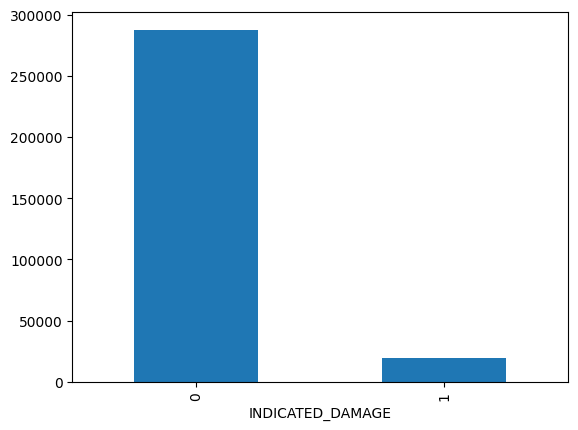

In [7]:
# This will display the distribution of the target variable, whether wildlife strike caused damage
# NOTES: this is an imbalanced distribution, we should not use accuracy as a metric and instead use confusion matrices
# With precision and recall to determine error
train_data["INDICATED_DAMAGE"].value_counts().plot.bar()

In [8]:
# Display the number of strikes based on state
train_data["STATE"].value_counts()

STATE
TX    27546
FL    22494
CA    21454
NY    14422
CO    13472
      ...  
MB       15
MH       12
NL        5
SK        5
NS        3
Name: count, Length: 67, dtype: int64

Determining Outliers using Box Plots

INCIDENT_MONTH             Axes(0.125,0.814746;0.133621x0.0652542)
INCIDENT_YEAR           Axes(0.285345,0.814746;0.133621x0.0652542)
AC_MASS                  Axes(0.44569,0.814746;0.133621x0.0652542)
NUM_ENGS                Axes(0.606034,0.814746;0.133621x0.0652542)
ENG_1_POS               Axes(0.766379,0.814746;0.133621x0.0652542)
ENG_2_POS                  Axes(0.125,0.736441;0.133621x0.0652542)
ENG_3_POS               Axes(0.285345,0.736441;0.133621x0.0652542)
ENG_4_POS                Axes(0.44569,0.736441;0.133621x0.0652542)
HEIGHT                  Axes(0.606034,0.736441;0.133621x0.0652542)
SPEED                   Axes(0.766379,0.736441;0.133621x0.0652542)
DISTANCE                   Axes(0.125,0.658136;0.133621x0.0652542)
OUT_OF_RANGE_SPECIES    Axes(0.285345,0.658136;0.133621x0.0652542)
REMAINS_COLLECTED        Axes(0.44569,0.658136;0.133621x0.0652542)
REMAINS_SENT            Axes(0.606034,0.658136;0.133621x0.0652542)
INDICATED_DAMAGE        Axes(0.766379,0.658136;0.133621x0.0652

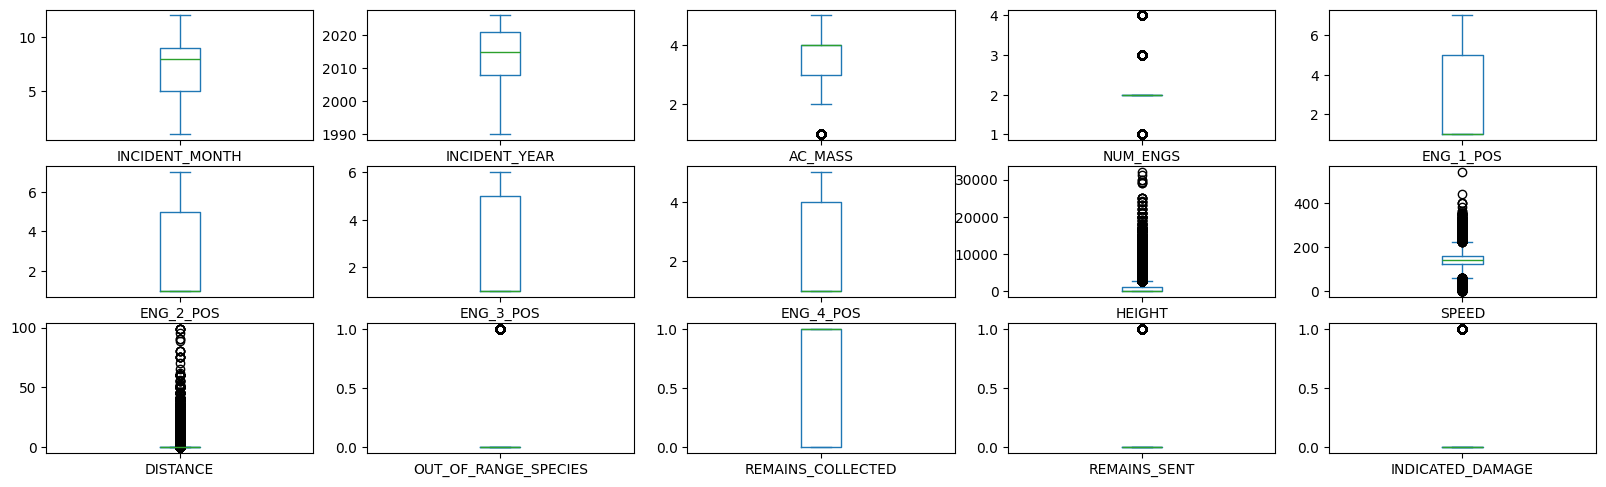

In [9]:
numeric_columns = train_data.select_dtypes(include='number')
numeric_columns.plot(kind='box', subplots=True, layout=(10, 5), figsize=(20,20))

Handling Missing Values

In [10]:
# Handling missing values
null_column_totals = train_data.isnull().sum().sort_values(ascending=False)
null_column_totals

ENG_4_POS               303909
ENROUTE_STATE           301832
PRECIPITATION           295966
ENG_3_POS               294822
SPEED                   212076
NUM_SEEN                208546
SKY                     162825
HEIGHT                  154197
TIME_OF_DAY             133971
PHASE_OF_FLIGHT         120961
DISTANCE                103303
ENG_2_POS               102509
TYPE_ENG                 87786
ENG_1_POS                87717
NUM_ENGS                 87697
AC_MASS                  87446
AC_CLASS                 87315
RUNWAY                   75585
LONGITUDE                40747
STATE                    40744
LATITUDE                 40744
SIZE                     33507
NUM_STRUCK                 647
REMAINS_COLLECTED            0
WARNED                       0
REMAINS_SENT                 0
INCIDENT_DATE                0
OUT_OF_RANGE_SPECIES         0
SPECIES_ID                   0
INCIDENT_MONTH               0
AIRCRAFT                     0
OPID                         0
AIRPORT_

In [11]:
# Imputation for LATITUDE and LONGITUDE
# We found when imputing that the latitude and longitude has some errors in the data 
# resulting in some entries to have commas which prevents us from calculating the mean
# Solution: drop records that contain invalid format
dms_count = train_data['LATITUDE'].astype(str).str.contains("°", na=False).sum()
total = len(train_data)
print(dms_count)

dms_count = train_data['LONGITUDE'].astype(str).str.contains("°", na=False).sum()
total_longitude = len(train_data)
print(dms_count)

# Drop records with latitude or longitude in DMS format
print(len(train_data))
train_data = train_data[~train_data['LATITUDE'].astype(str).str.contains("°", na=False)]
train_data = train_data[~train_data['LONGITUDE'].astype(str).str.contains("°", na=False)]
print(len(train_data))

# Ensure latitude and longitude are formatted correctly to perform aggregate functions
train_data["LATITUDE"] = train_data["LATITUDE"].astype(str).str.replace(",", "")
train_data["LONGITUDE"] = train_data["LONGITUDE"].astype(str).str.replace(",", "")
train_data["LATITUDE"] = pd.to_numeric(train_data["LATITUDE"], errors="coerce")
train_data["LONGITUDE"] = pd.to_numeric(train_data["LONGITUDE"], errors="coerce")

test_data["LATITUDE"] = test_data["LATITUDE"].astype(str).str.replace(",", "")
test_data["LONGITUDE"] = test_data["LONGITUDE"].astype(str).str.replace(",", "")
test_data["LATITUDE"] = pd.to_numeric(test_data["LATITUDE"], errors="coerce")
test_data["LONGITUDE"] = pd.to_numeric(test_data["LONGITUDE"], errors="coerce")

print("Number of null values before imputation")
print(train_data["LATITUDE"].isnull().sum())
print(train_data["LONGITUDE"].isnull().sum())

# Group by airport id and impute using median
latitude_based_on_airport = train_data.groupby("AIRPORT_ID")["LATITUDE"].transform("median")
longitude_based_on_airport = train_data.groupby("AIRPORT_ID")["LONGITUDE"].transform("median")
train_data['LATITUDE'] = train_data['LATITUDE'].fillna(latitude_based_on_airport)
train_data['LONGITUDE'] = train_data['LONGITUDE'].fillna(longitude_based_on_airport)
# Impute remainders using overall median if no airport id found
train_data['LATITUDE'] = train_data['LATITUDE'].fillna(train_data["LATITUDE"].median())
train_data['LONGITUDE'] = train_data['LONGITUDE'].fillna(train_data["LONGITUDE"].median())

# Using the mapping created on the training data, use to impute test data as well
test_data['LATITUDE'] = test_data['LATITUDE'].fillna(latitude_based_on_airport)
test_data['LONGITUDE'] = test_data['LONGITUDE'].fillna(longitude_based_on_airport)
# Avoid data leakage: fill remainders with median from training data
test_data['LATITUDE'] = test_data['LATITUDE'].fillna(train_data["LATITUDE"].median())
test_data['LONGITUDE'] = test_data['LONGITUDE'].fillna(train_data["LONGITUDE"].median())


print("After imputation, check that no null values remain")
print(train_data["LATITUDE"].isnull().sum())
print(train_data["LONGITUDE"].isnull().sum())

4
1
307178
307174
Number of null values before imputation
40751
40746
After imputation, check that no null values remain
0
0


In [12]:
# If STATE is null, impute using ENROUTE_STATE, then remove ENROUTE_STATE column in the end
# Make a mask to show the records that enroute state has values for
# Make a mask for the records that STATE is null in
# Compute intersection between masks to get records that will be imputed with ENROUTE_STATE
# Fill missing STATE using ENROUTE_STATE
print("Pre fill: ", train_data["STATE"].isnull().sum())
train_data['STATE'] = train_data['STATE'].fillna(train_data['ENROUTE_STATE'])
test_data['STATE'] = test_data['STATE'].fillna(test_data['ENROUTE_STATE'])
print("Post fill: ", train_data["STATE"].isnull().sum())

# Drop ENROUTE_STATE
train_data = train_data.drop(columns=['ENROUTE_STATE'])
test_data = test_data.drop(columns=['ENROUTE_STATE'])

# Similar case imputation based on AIRPORT_ID since there is no null values present
print("Null entries before imputation", train_data["STATE"].isnull().sum(), "\n")
airport_states = train_data.groupby("AIRPORT_ID")["STATE"].transform("first")
train_data["STATE"] = train_data["STATE"].fillna(airport_states)
print("Null entries after imputation", train_data["STATE"].isnull().sum(), "\n")

airport_states = test_data.groupby("AIRPORT_ID")["STATE"].transform("first")
test_data["STATE"] = test_data["STATE"].fillna(airport_states)

# We have 11 remaining null entries, we can then drop those records with null states
train_data = train_data.dropna(subset=["STATE"])
print("Null entries after dropping remainder", train_data["STATE"].isnull().sum(), "\n")

# Standardize foreign STATE to only have one value (currently FN/FGN)
train_data["STATE"] = train_data["STATE"].replace("FN", "FGN")
test_data["STATE"] = test_data["STATE"].replace("FN", "FGN")

Pre fill:  40744
Post fill:  35400
Null entries before imputation 35400 

Null entries after imputation 18 

Null entries after dropping remainder 0 



In [13]:
# Similar Case imputation for SIZE based on SPECIES_ID since we have no null values there
# However we found that this did not work, each null entry in SIZE corresponded with Unknown 
# Bird SPECIES (UNKB SPECIES_ID) which all contained null for size
size = train_data["SIZE"].isnull()
species_id = train_data["SPECIES_ID"].isnull()
shared_null_2 = (size & species_id).sum()
print(size.sum())
print(species_id.sum())
print(shared_null_2)

print("Null entries after imputation", train_data["SIZE"].isnull().sum(), "\n")
species_sizes = (train_data.dropna(subset=["SIZE"]).groupby("SPECIES_ID")["SIZE"].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None))
train_data["SIZE"] = train_data["SIZE"].fillna(train_data["SPECIES_ID"].map(species_sizes))
test_data["SIZE"] = test_data["SIZE"].fillna(test_data["SPECIES_ID"].map(species_sizes))

# Chose to impute null entries in SIZE with medium
train_data["SIZE"] = train_data["SIZE"].fillna("Medium")
test_data["SIZE"] = test_data["SIZE"].fillna("Medium")
print("Null entries after imputation", train_data["SIZE"].isnull().sum(), "\n")

33507
0
0
Null entries after imputation 33507 

Null entries after imputation 0 



In [14]:
# Impute null values in RUNWAY
# RUNWAY - Runway designation where the strike occurred (blank if airborne).
# Null values exist but they have meaning (airborne)
print("Null entries before imputation", train_data["RUNWAY"].isnull().sum(), "\n")
train_data["RUNWAY"] = train_data["RUNWAY"].fillna("AIRBORNE")
test_data["RUNWAY"] = test_data["RUNWAY"].fillna("AIRBORNE")
print("Null entries after imputation", train_data["RUNWAY"].isnull().sum(), "\n")

Null entries before imputation 75568 

Null entries after imputation 0 



In [15]:
# AC_CLASS - Aircraft class (A = airplane, B = helicopter, C = glider, J = ultralight, Y = other).
print("Null entries before imputation", train_data["AC_CLASS"].isnull().sum(), "\n")
ac_class_impute = "U"
train_data["AC_CLASS"] = train_data["AC_CLASS"].fillna(ac_class_impute)
test_data["AC_CLASS"] = test_data["AC_CLASS"].fillna(ac_class_impute)
print("Null entries after imputation", train_data["AC_CLASS"].isnull().sum(), "\n")

Null entries before imputation 87315 

Null entries after imputation 0 



In [16]:
# AC_MASS - Aircraft weight class (1 = 2,250 kg or less through 5 = above 272,000 kg).
# Impute using mode
print("Null entries before imputation", train_data["AC_MASS"].isnull().sum(), "\n")
ac_mass_impute = train_data["AC_MASS"].mode()[0]
train_data["AC_MASS"] = train_data["AC_MASS"].fillna(ac_mass_impute)
test_data["AC_MASS"] = test_data["AC_MASS"].fillna(ac_mass_impute)
print("Null entries after imputation", train_data["AC_MASS"].isnull().sum(), "\n")


Null entries before imputation 87446 

Null entries after imputation 0 



In [17]:
# NUM_ENGS - Number of engines on the aircraft.
# Impute using median
print("Null entries before imputation", train_data["NUM_ENGS"].isnull().sum(), "\n")
num_engs_impute = train_data["NUM_ENGS"].median()
train_data["NUM_ENGS"] = train_data["NUM_ENGS"].fillna(num_engs_impute)
test_data["NUM_ENGS"] = test_data["NUM_ENGS"].fillna(num_engs_impute)
print("Null entries after imputation", train_data["NUM_ENGS"].isnull().sum(), "\n")

Null entries before imputation 87697 

Null entries after imputation 0 



In [18]:
# ENG_1_POS - The mounting position of engine 1 on the aircraft.
# Impute using median
print("Null entries before imputation", train_data["ENG_1_POS"].isnull().sum(), "\n")
eng_1_pos_impute = train_data["ENG_1_POS"].mode()
train_data["ENG_1_POS"] = train_data["ENG_1_POS"].fillna(eng_1_pos_impute)
# Use mode of training data to avoid data leakage
test_data["ENG_1_POS"] = test_data["ENG_1_POS"].fillna(eng_1_pos_impute)
print("Null entries after imputation", train_data["ENG_1_POS"].isnull().sum(), "\n")

Null entries before imputation 87717 

Null entries after imputation 87717 



In [19]:
# TYPE_ENG - The type of engine.
# Fill missing values with U for unknown
print("Null entries after imputation", train_data["TYPE_ENG"].isnull().sum(), "\n")
train_data["TYPE_ENG"] = train_data["TYPE_ENG"].fillna("U")
test_data["TYPE_ENG"] = test_data["TYPE_ENG"].fillna("U")
print("Null entries after imputation", train_data["TYPE_ENG"].isnull().sum(), "\n")

Null entries after imputation 87786 

Null entries after imputation 0 



In [20]:
# PRECIPITATION
# Fill missing values with None based on Kaggle column description
train_data["PRECIPITATION"] = train_data["PRECIPITATION"].fillna("None")
train_data["PRECIPITATION"].value_counts()

test_data["PRECIPITATION"] = test_data["PRECIPITATION"].fillna("None")
test_data["PRECIPITATION"].value_counts()

PRECIPITATION
None          32906
Rain            831
Fog             283
Snow             69
Fog, Rain        37
Rain, Snow        4
None, Rain        1
Name: count, dtype: int64

In [21]:
# Imputation for PHASE_OF_FLIGHT
# Possible Values: Approach, Climb, Descent, En Route, Landing Roll, Parked, Take-off Run, Taxi
print("Null entries before imputation", train_data["PHASE_OF_FLIGHT"].isnull().sum(), "\n")
print(train_data["PHASE_OF_FLIGHT"].value_counts())
train_data["PHASE_OF_FLIGHT"] = train_data["PHASE_OF_FLIGHT"].fillna("UNKNOWN")
test_data["PHASE_OF_FLIGHT"] = test_data["PHASE_OF_FLIGHT"].fillna("UNKNOWN")
print("Null entries after imputation", train_data["RUNWAY"].isnull().sum(), "\n")


Null entries before imputation 120961 

PHASE_OF_FLIGHT
Approach        79157
Landing Roll    33635
Take-off Run    31006
Climb           27444
En Route         5600
Departure        3569
Descent          2630
Local            1368
Arrival           958
Taxi              717
Parked            102
Unknown             9
Name: count, dtype: int64
Null entries after imputation 0 



In [22]:
# Impute AC Mass using mode
print("Null entries before imputation", train_data["AC_MASS"].isnull().sum(), "\n")
print(train_data["AC_MASS"].value_counts())
train_data["AC_MASS"] = train_data["AC_MASS"].fillna(train_data["AC_MASS"].mode()[0])
test_data["AC_MASS"] = test_data["AC_MASS"].fillna(train_data["AC_MASS"].mode()[0])
print("Null entries after imputation", train_data["AC_MASS"].isnull().sum(), "\n")



Null entries before imputation 0 

AC_MASS
4.0    244700
3.0     33443
2.0     13442
1.0     13091
5.0      2480
Name: count, dtype: int64
Null entries after imputation 0 



In [23]:
# Impute NUM_STRUCK
print("Null entries after imputation", train_data["NUM_STRUCK"].isnull().sum(), "\n")
train_data["NUM_STRUCK"] = train_data["NUM_STRUCK"].fillna("UNKNOWN")
test_data["NUM_STRUCK"] = test_data["NUM_STRUCK"].fillna("UNKNOWN")
print(train_data["NUM_STRUCK"].value_counts())
print("Null entries after imputation", train_data["NUM_STRUCK"].isnull().sum(), "\n")


Null entries after imputation 640 

NUM_STRUCK
1                273266
10-Feb            31697
11-100             1502
UNKNOWN             640
More than 100        51
Name: count, dtype: int64
Null entries after imputation 0 



In [24]:
# Impute HEIGHT
print("Null entries after imputation", train_data["HEIGHT"].isnull().sum(), "\n")
print(train_data["HEIGHT"].value_counts())
# If HEIGHT is null and phase is either Parked, Taxi, or Landing Roll, impute with 0
height_0_phases = ["Parked", "Taxi", "Landing Roll"]
# Create a mask to identify flights in these phases
train_mask = train_data["PHASE_OF_FLIGHT"].isin(height_0_phases)
test_mask = test_data["PHASE_OF_FLIGHT"].isin(height_0_phases)
train_data.loc[train_mask & train_data["HEIGHT"].isnull(), "HEIGHT"] = 0
test_data.loc[test_mask & test_data["HEIGHT"].isnull(), "HEIGHT"] = 0

# Otherwise impute with median FROM TRAINING DATA (prevent data leakage)
height_to_impute = train_data["HEIGHT"].median()
train_data.loc[~train_mask, "HEIGHT"] = train_data.loc[~train_mask, "HEIGHT"].fillna(height_to_impute)
test_data.loc[~test_mask, "HEIGHT"] = test_data.loc[~test_mask, "HEIGHT"].fillna(height_to_impute)

print("Null entries after imputation", train_data["HEIGHT"].isnull().sum(), "\n")

Null entries after imputation 154195 

HEIGHT
0.0       65563
100.0      6528
50.0       5742
500.0      5307
1000.0     5183
          ...  
1525.0        1
1029.0        1
2231.0        1
7350.0        1
990.0         1
Name: count, Length: 708, dtype: int64
Null entries after imputation 0 



In [25]:
# Impute SPEED: group data based on the type of engine that the aircraft uses
# Since similar engines will likely have similar speeds
# Then use the median of the groupings
print("Null entries before imputation", train_data["SPEED"].isnull().sum(), "\n")
speed_to_impute = train_data.groupby("TYPE_ENG")["SPEED"].transform("median")
train_data["SPEED"] = train_data["SPEED"].fillna(speed_to_impute)
test_data["SPEED"] = test_data["SPEED"].fillna(speed_to_impute)
# otherwise impute the rest with overall median
train_data["SPEED"] = train_data["SPEED"].fillna(train_data["SPEED"].median())
test_data["SPEED"] = test_data["SPEED"].fillna(train_data["SPEED"].median())
print("Null entries after imputation", train_data["SPEED"].isnull().sum(), "\n")

Null entries before imputation 212068 

Null entries after imputation 0 



In [26]:
# Impute SKY with unknown
print("Null entries after imputation", train_data["SKY"].isnull().sum(), "\n")
print(train_data["SKY"].value_counts())
train_data["SKY"] = train_data["SKY"].fillna("Unknown")
test_data["SKY"] = test_data["SKY"].fillna("Unknown")
print("Null entries after imputation", train_data["SKY"].isnull().sum(), "\n")

Null entries after imputation 162812 

SKY
No Cloud      70572
Some Cloud    49702
Overcast      24070
Name: count, dtype: int64
Null entries after imputation 0 



In [27]:
print("Null entries after imputation", train_data["TIME_OF_DAY"].isnull().sum(), "\n")
print(train_data["TIME_OF_DAY"].value_counts())
train_data["TIME_OF_DAY"] = train_data["TIME_OF_DAY"].fillna("Unknown")
test_data["TIME_OF_DAY"] = test_data["TIME_OF_DAY"].fillna("Unknown")
print("Null entries after imputation", train_data["TIME_OF_DAY"].isnull().sum(), "\n")


Null entries after imputation 133965 

TIME_OF_DAY
Day      105748
Night     53906
Dusk       7621
Dawn       5916
Name: count, dtype: int64
Null entries after imputation 0 



In [28]:
# Impute DISTANCE based on phase of flight. Phase of flight will determine how far an aircraft may be
# Group based on phase of flight and impute using median distance within that phase
distance_to_impute = train_data.groupby("PHASE_OF_FLIGHT")["DISTANCE"].transform("median")
train_data["DISTANCE"] = train_data["DISTANCE"].fillna(distance_to_impute)
test_data["DISTANCE"] = test_data["DISTANCE"].fillna(distance_to_impute)

In [29]:
# Check to see if number of engines and missing values in END_X_POS correlate
train_data[["NUM_ENGS", "ENG_1_POS", "ENG_2_POS", "ENG_3_POS", "ENG_4_POS"]].head(20)
# Findings: Number of engines reported TYPICALLY (not always) corresponds with the number of non null values in ENG_1_POS.
# if only 2 engines, END_1_POS and ENG_2_POS equal

,NUM_ENGS,ENG_1_POS,ENG_2_POS,ENG_3_POS,ENG_4_POS
0,3.0,5.0,6.0,5.0,NaN
1,3.0,1.0,6.0,1.0,NaN
2,2.0,1.0,1.0,NaN,NaN
3,2.0,NaN,NaN,NaN,NaN
4,2.0,1.0,1.0,NaN,NaN
5,2.0,1.0,1.0,NaN,NaN
6,2.0,1.0,1.0,NaN,NaN
7,2.0,5.0,5.0,NaN,NaN
8,2.0,1.0,1.0,NaN,NaN
9,2.0,1.0,1.0,NaN,NaN


In [30]:
print(train_data["NUM_SEEN"].value_counts())
print(train_data["ENG_1_POS"].value_counts())
print(train_data["ENG_2_POS"].value_counts())
print(train_data["ENG_3_POS"].value_counts())
print(train_data["ENG_4_POS"].value_counts())

NUM_SEEN
1                60289
10-Feb           30128
11-100            7220
More than 100      977
Name: count, dtype: int64
ENG_1_POS
1.0    128215
5.0     58105
4.0     15841
7.0     12379
6.0      4625
3.0       218
2.0        56
Name: count, dtype: int64
ENG_2_POS
1.0    124289
5.0     52894
4.0     15829
6.0     11383
3.0       218
2.0        50
7.0         1
Name: count, dtype: int64
ENG_3_POS
1.0    6213
5.0    5173
4.0     963
3.0       5
6.0       1
Name: count, dtype: int64
ENG_4_POS
1.0    2005
4.0    1245
5.0      13
3.0       5
Name: count, dtype: int64


In [31]:
# Impute NUM_SEEN by first normalizing the data to be only numeric
num_seen_values = {
    "1": 1,
    "10-Feb": 5,
    "11-100": 50,
    "More than 100": 150
}

train_data["NUM_SEEN"] = train_data["NUM_SEEN"].map(num_seen_values)
test_data["NUM_SEEN"] = test_data["NUM_SEEN"].map(num_seen_values)

In [32]:
# Check that all values have been correctly filled in
# Handling missing values
null_column_totals = train_data.isnull().sum().sort_values(ascending=False)
null_column_totals

ENG_4_POS               303888
ENG_3_POS               294801
NUM_SEEN                208542
ENG_2_POS               102492
ENG_1_POS                87717
PRECIPITATION                0
HEIGHT                       0
SPEED                        0
DISTANCE                     0
SKY                          0
SPECIES_ID                   0
OUT_OF_RANGE_SPECIES         0
REMAINS_COLLECTED            0
REMAINS_SENT                 0
WARNED                       0
NUM_STRUCK                   0
SIZE                         0
PHASE_OF_FLIGHT              0
INCIDENT_DATE                0
INCIDENT_MONTH               0
NUM_ENGS                     0
TYPE_ENG                     0
AC_MASS                      0
AC_CLASS                     0
AIRCRAFT                     0
OPID                         0
STATE                        0
RUNWAY                       0
LONGITUDE                    0
LATITUDE                     0
AIRPORT_ID                   0
TIME_OF_DAY                  0
INCIDENT

## Feature Engineering

Create a feature based on NUM_STRUCK to check is multiple struck

In [33]:
train_data["SIZE"].value_counts()
train_data["NUM_STRUCK"].value_counts()

NUM_STRUCK
1                273266
10-Feb            31697
11-100             1502
UNKNOWN             640
More than 100        51
Name: count, dtype: int64

In [34]:
# Create feature based on NUM_STRUCK and SIZE
# SIZE is a string value; map to numerical values to calculate severity of impact by multiplying SIZE * NUM_STRUCK
train_data["SIZE"] = train_data["SIZE"].map({
    "Small": 1,
    "Medium": 2,
    "Large": 3
})
# NUM_STRUCK is a range string value, map to numerical value to reflect impact
train_data["NUM_STRUCK"] = train_data["NUM_STRUCK"].map({
    "1": 1,
    "10-Feb": 5,
    "11-100": 10,
    "More than 100": 100
})
# Calculate severity of impact by multiplying SIZE_NUM * NUM_STRUCK
train_data["SEVERITY"] = train_data["NUM_STRUCK"] * train_data["SIZE"]
# Impute any null entries with the median
train_data["SEVERITY"] = train_data["SEVERITY"].fillna(train_data["SEVERITY"].median())


test_data["SIZE"] = test_data["SIZE"].map({
    "Small": 1,
    "Medium": 2,
    "Large": 3
})
# NUM_STRUCK is a range string value, map to numerical value to reflect impact
test_data["NUM_STRUCK"] = test_data["NUM_STRUCK"].map({
    "1": 1,
    "10-Feb": 5,
    "11-100": 10,
    "More than 100": 100
})
# Calculate severity of impact by multiplying SIZE_NUM * NUM_STRUCK
test_data["SEVERITY"] = test_data["NUM_STRUCK"] * test_data["SIZE"]
test_data["SEVERITY"] = test_data["SEVERITY"].fillna(train_data["SEVERITY"].median())
print("Null entries after creation", train_data["SEVERITY"].isnull().sum(), "\n")

Null entries after creation 0 



In [35]:
# Create a feature based on season of impact
train_data["SEASON"] = train_data["INCIDENT_MONTH"].apply(lambda x: (x % 12 // 3) + 1)

test_data["SEASON"] = test_data["INCIDENT_MONTH"].apply(lambda x: (x % 12 // 3) + 1)
print("Null entries after creation", train_data["SEASON"].isnull().sum(), "\n")

Null entries after creation 0 



In [36]:
# Create feature of whether the aircraft was airborne or not depending on the value of RUNWAY
# RUNWAY has MANY different values (over 1000)
print(train_data["RUNWAY"].value_counts())
train_data["IS_AIRBORNE"] = (train_data["RUNWAY"] == "AIRBORNE").astype(int)
test_data["IS_AIRBORNE"] = (test_data["RUNWAY"] == "AIRBORNE").astype(int)
# Drop RUNWAY
train_data = train_data.drop(columns=["RUNWAY"])
test_data = test_data.drop(columns=["RUNWAY"])

RUNWAY
AIRBORNE             75568
27                    4180
22L                   4018
17R                   3993
22                    3794
                     ...  
L1                       1
19 R                     1
TWY C @ RWY 13/31        1
18R/26L                  1
TWY K6                   1
Name: count, Length: 1363, dtype: int64


## Handling Categorical Features: One Hot Encoding

In [37]:
# Get list of columns
train_data.columns

Index(['INCIDENT_DATE', 'INCIDENT_MONTH', 'INCIDENT_YEAR', 'TIME_OF_DAY',
       'AIRPORT_ID', 'LATITUDE', 'LONGITUDE', 'STATE', 'OPID', 'AIRCRAFT',
       'AC_CLASS', 'AC_MASS', 'TYPE_ENG', 'NUM_ENGS', 'ENG_1_POS', 'ENG_2_POS',
       'ENG_3_POS', 'ENG_4_POS', 'PHASE_OF_FLIGHT', 'HEIGHT', 'SPEED',
       'DISTANCE', 'SKY', 'PRECIPITATION', 'SPECIES_ID',
       'OUT_OF_RANGE_SPECIES', 'REMAINS_COLLECTED', 'REMAINS_SENT', 'WARNED',
       'NUM_SEEN', 'NUM_STRUCK', 'SIZE', 'INDICATED_DAMAGE', 'SEVERITY',
       'SEASON', 'IS_AIRBORNE'],
      dtype='object')

In [38]:
train_data = train_data.drop(columns=["INCIDENT_DATE"])
test_data = test_data.drop(columns=["INCIDENT_DATE"])

In [39]:
# Using CatBoost: no need to use one hot encoding or frequency encoding due to categorical variable handling by model
categorical_cols = ['TIME_OF_DAY', 'AIRPORT_ID', 'STATE', 'OPID', 
                    'AIRCRAFT', 'AC_CLASS', 'TYPE_ENG', 
                    'PHASE_OF_FLIGHT', 'SKY', 'PRECIPITATION', 
                    'SPECIES_ID', 'SKY', 'WARNED', 'TYPE_ENG']
# Handling missing values
null_column_totals = train_data.isnull().sum().sort_values(ascending=False)
print("Number missing values for each column\n", null_column_totals)

for col in categorical_cols:
    train_data[col] = train_data[col].fillna("Unknown").astype(str)
    test_data[col] = test_data[col].fillna("Unknown").astype(str)


Number missing values for each column
 ENG_4_POS               303888
ENG_3_POS               294801
NUM_SEEN                208542
ENG_2_POS               102492
ENG_1_POS                87717
NUM_STRUCK                 640
INCIDENT_MONTH               0
OUT_OF_RANGE_SPECIES         0
PRECIPITATION                0
SPECIES_ID                   0
REMAINS_SENT                 0
REMAINS_COLLECTED            0
DISTANCE                     0
WARNED                       0
SIZE                         0
INDICATED_DAMAGE             0
SEVERITY                     0
SEASON                       0
SKY                          0
PHASE_OF_FLIGHT              0
SPEED                        0
HEIGHT                       0
INCIDENT_YEAR                0
NUM_ENGS                     0
TYPE_ENG                     0
AC_MASS                      0
AC_CLASS                     0
AIRCRAFT                     0
OPID                         0
STATE                        0
LONGITUDE                    0


In [40]:
import numpy as np

from catboost import CatBoostClassifier, Pool
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split

# initialize data
X = train_data.drop("INDICATED_DAMAGE", axis=1)
y = train_data["INDICATED_DAMAGE"]
X_test = test_data.copy()

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = CatBoostClassifier(iterations=1000,
                           depth=6,
                           learning_rate=0.05,
                           loss_function='Logloss',
                           eval_metric='AUC',
                           auto_class_weights = "Balanced",
                           verbose=100)
# train the model
model.fit(X_train, y_train, cat_features=categorical_cols, eval_set=(X_val, y_val), use_best_model=True)
# make the prediction on the validation set using the resulting model
val_probabilities = model.predict_proba(X_val)[:, 1]
val_predictions = (val_probabilities >= 0.5).astype(int)
score = balanced_accuracy_score(y_val, val_predictions)
print(f"Balanced Accuracy: {score:.4f}")

# Separately generate submission predictions on test set
test_probabilities = model.predict_proba(X_test)[:, 1]
test_predictions = (test_probabilities >= 0.5).astype(int)

0:	test: 0.8645090	best: 0.8645090 (0)	total: 218ms	remaining: 3m 38s
100:	test: 0.9062642	best: 0.9062642 (100)	total: 13.2s	remaining: 1m 57s
200:	test: 0.9105856	best: 0.9105856 (200)	total: 27s	remaining: 1m 47s
300:	test: 0.9130665	best: 0.9130665 (300)	total: 42.8s	remaining: 1m 39s
400:	test: 0.9144677	best: 0.9144726 (398)	total: 58.3s	remaining: 1m 27s
500:	test: 0.9149131	best: 0.9149131 (500)	total: 1m 13s	remaining: 1m 13s
600:	test: 0.9151337	best: 0.9151494 (596)	total: 1m 28s	remaining: 59s
700:	test: 0.9152574	best: 0.9152772 (681)	total: 1m 44s	remaining: 44.4s
800:	test: 0.9153031	best: 0.9153110 (784)	total: 2m 1s	remaining: 30.2s
900:	test: 0.9153072	best: 0.9153175 (868)	total: 2m 18s	remaining: 15.2s
999:	test: 0.9152791	best: 0.9154037 (959)	total: 2m 37s	remaining: 0us

bestTest = 0.9154036585
bestIteration = 959

Shrink model to first 960 iterations.
Balanced Accuracy: 0.8292


In [41]:
# # need to one hot encode categorical variables
# # categorical_columns =['NUM_STRUCK', 'TIME_OF_DAY', 'AIRPORT_ID', 'RUNWAY', 'STATE', 'FAAREGION', 'LOCATION', 'OPID', 'AIRCRAFT', 'AC_CLASS', 'TYPE_ENG', 'PHASE_OF_FLIGHT', 'SKY', 'SPECIES_ID', 'WARNED', 'SIZE', 'ENROUTE_STATE', 'SOURCE', 'PERSON']
# # categorical_columns =['AIRPORT_ID', 'RUNWAY', 'STATE', 'OPID', 'AIRCRAFT', 'AC_CLASS', 'TYPE_ENG', 'SPECIES_ID', 'PRECIPITATION']
# categorical_columns =['AC_CLASS', 'TYPE_ENG', 'PRECIPITATION']
# train_data = pd.get_dummies(train_data, columns = categorical_columns, drop_first=True)

# test_data = pd.get_dummies(test_data, columns = categorical_columns, drop_first=True)


# # WHAT TO ONE HOT ENCODE
# # NUM_STRUCK, TIME_OF_DAY, AIRPORT_ID, RUNWAY, STATE, FAAREGION, LOCATION, OPID, AIRCRAFT, AC_CLASS, TYPE_ENG, PHASE_OF_FLIGHT, SKY, SPECIES_ID, 
# # WARNED, SIZE, ENROUTE_STATE, SOURCE, PERSON

# train_data.head()

## Handling High Cardinality Categorical Features: Frequency Encoding

In [42]:
# # Use frequency encoding for SPECIES_ID since high cardinality categorical variable (over 900 different values)
# frequency_encoding = train_data["SPECIES_ID"].value_counts()
# print("Number of values in SPECIES_ID:", len(frequency_encoding))
# train_data["SPECIES_ID_FREQ"] = train_data["SPECIES_ID"].map(frequency_encoding)
# train_data = train_data.drop(columns=["SPECIES_ID"])

# test_data["SPECIES_ID_FREQ"] = test_data["SPECIES_ID"].map(frequency_encoding)
# test_data = test_data.drop(columns=["SPECIES_ID"])
# test_data["SPECIES_ID_FREQ"] = test_data["SPECIES_ID_FREQ"].fillna(0)

In [43]:
# # Use frequency encoding for AIRPORT_ID since high cardinality categorical variable (over 2600 different values)
# frequency_encoding = train_data["AIRPORT_ID"].value_counts()
# print("Number of values in AIRPORTID:", len(frequency_encoding))
# train_data["AIRPORT_ID_FREQ"] = train_data["AIRPORT_ID"].map(frequency_encoding)
# train_data = train_data.drop(columns=["AIRPORT_ID"])

# # test
# test_data["AIRPORT_ID_FREQ"] = test_data["AIRPORT_ID"].map(frequency_encoding)
# test_data = test_data.drop(columns=["AIRPORT_ID"])
# test_data["AIRPORT_ID_FREQ"] = test_data["AIRPORT_ID_FREQ"].fillna(0)

In [44]:
# # Use frequency encoding for OPID since high cardinality categorical variable (over 600 different values)
# frequency_encoding = train_data["OPID"].value_counts()
# print("Number of values in OPID:", len(frequency_encoding))
# train_data["OPID_FREQ"] = train_data["OPID"].map(frequency_encoding)
# train_data = train_data.drop(columns=["OPID"])

# test_data["OPID_FREQ"] = test_data["OPID"].map(frequency_encoding)
# test_data = test_data.drop(columns=["OPID"])
# test_data["OPID_FREQ"] = test_data["OPID_FREQ"].fillna(0)

In [45]:
# # Use frequency encoding for AIRCRAFT since high cardinality categorical variable (over 600 different values)
# frequency_encoding = train_data["AIRCRAFT"].value_counts()
# print("Number of values in AIRCRAFT:", len(frequency_encoding))
# train_data["AIRCRAFT_FREQ"] = train_data["AIRCRAFT"].map(frequency_encoding)
# train_data = train_data.drop(columns=["AIRCRAFT"])

# test_data["AIRCRAFT_FREQ"] = test_data["AIRCRAFT"].map(frequency_encoding)
# test_data = test_data.drop(columns=["AIRCRAFT"])
# test_data["AIRCRAFT_FREQ"] = test_data["AIRCRAFT_FREQ"].fillna(0)

In [46]:
# # Use frequency encoding for RUNWAY since high cardinality categorical variable (over 1300 different values)
# frequency_encoding = train_data["RUNWAY"].value_counts()
# print("Number of values in RUNWAY:", len(frequency_encoding))
# train_data["RUNWAY_FREQ"] = train_data["RUNWAY"].map(frequency_encoding)
# train_data = train_data.drop(columns=["RUNWAY"])

# test_data["RUNWAY_FREQ"] = test_data["RUNWAY"].map(frequency_encoding)
# test_data = test_data.drop(columns=["RUNWAY"])
# test_data["RUNWAY_FREQ"] = test_data["RUNWAY_FREQ"].fillna(0)

In [47]:
# # Use frequency encoding for STATE since high cardinality categorical variable (over 1300 different values)
# frequency_encoding = train_data["STATE"].value_counts()
# print("Number of values in STATE:", len(frequency_encoding))
# train_data["STATE_FREQ"] = train_data["STATE"].map(frequency_encoding)
# train_data = train_data.drop(columns=["STATE"])

# test_data["STATE_FREQ"] = test_data["STATE"].map(frequency_encoding)
# test_data = test_data.drop(columns=["STATE"])
# test_data["STATE_FREQ"] = test_data["STATE_FREQ"].fillna(0)

## Dimensionality Reduction

In [48]:
# # Scale data so that all features are on the same scale
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA

# sc = StandardScaler()
# numpy_array_data = sc.fit_transform(train_data)
# scaled_data = pd.DataFrame(numpy_array_data, columns=train_data.columns)

# numpy_array_data = sc.fit_transform(test_data)
# scaled_data = pd.DataFrame(numpy_array_data, columns=test_data.columns)

# print("Head of Scaled Data\n") 
# scaled_data.head()

In [49]:
train_data.columns.tolist()

['INCIDENT_MONTH',
 'INCIDENT_YEAR',
 'TIME_OF_DAY',
 'AIRPORT_ID',
 'LATITUDE',
 'LONGITUDE',
 'STATE',
 'OPID',
 'AIRCRAFT',
 'AC_CLASS',
 'AC_MASS',
 'TYPE_ENG',
 'NUM_ENGS',
 'ENG_1_POS',
 'ENG_2_POS',
 'ENG_3_POS',
 'ENG_4_POS',
 'PHASE_OF_FLIGHT',
 'HEIGHT',
 'SPEED',
 'DISTANCE',
 'SKY',
 'PRECIPITATION',
 'SPECIES_ID',
 'OUT_OF_RANGE_SPECIES',
 'REMAINS_COLLECTED',
 'REMAINS_SENT',
 'WARNED',
 'NUM_SEEN',
 'NUM_STRUCK',
 'SIZE',
 'INDICATED_DAMAGE',
 'SEVERITY',
 'SEASON',
 'IS_AIRBORNE']

In [50]:
# Apply PCA Reduction
# PCA reduces the dimensionality of the database (less columns)
# pca = PCA(n_components=0.95, svd_solver='full') #reduces to number dimensions needed to retain 95% of variance
# X_pca = pca.fit_transform(numpy_array_data)
# pca_data = pd.DataFrame(X_pca)
# pca_data.head()  

# Machine Learning Models

## Random Forest Ensembles: Bagging

Bagging is the default for base estimators

In [51]:
# # Random Forest Ensemble
# from sklearn.model_selection import train_test_split, cross_val_score
# from sklearn.metrics import accuracy_score, classification_report, balanced_accuracy_score
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.ensemble import BaggingClassifier
# from sklearn.tree import DecisionTreeClassifier

# data_X = train_data.drop(columns=['INDICATED_DAMAGE'])
# data_y = train_data['INDICATED_DAMAGE'].values.ravel()
# X_train, X_test, y_train, y_test = train_test_split(data_X, data_y, test_size = 0.2, random_state=42)

# model = RandomForestClassifier(n_estimators=300, max_depth=None, class_weight = 'balanced', random_state=0) 
# # Check using cross validation to train the model
# scores = cross_val_score(model, X_train, y_train, cv=5)
# print("Scores: ", scores)

# model.fit(X_train, y_train)

# y_pred = model.predict(X_test)

# print("Classification Report")
# print(classification_report(y_test, y_pred))
# print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))


## Random Forest Ensembles: Boosting

Ensemble classifer training using boosting

In [52]:
# from sklearn.ensemble import AdaBoostClassifier
# from sklearn.metrics import classification_report, balanced_accuracy_score

# clf = AdaBoostClassifier(n_estimators=200, learning_rate=1.0)
# clf.fit(X_train, y_train)
# y_pred = clf.predict(X_test)
# print("Classification Report") 
# print(classification_report(y_test, y_pred))
# print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))

In [53]:
# from sklearn.ensemble import GradientBoostingClassifier
# from sklearn.metrics import classification_report, balanced_accuracy_score

# clf = GradientBoostingClassifier(n_estimators=200, learning_rate=1.0, max_depth=5, subsample=0.8, min_samples_leaf=20)
# clf.fit(X_train, y_train)
# y_pred = clf.predict(X_test)
# print("Classification Report") 
# print(classification_report(y_test, y_pred))
# print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))

In [54]:
# from sklearn.metrics import balanced_accuracy_score
# from xgboost import XGBClassifier
# clf = XGBClassifier(
#     n_estimators=500,
#     learning_rate=0.05,
#     max_depth=6,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     eval_metric="logloss",
#     random_state=42,
#     n_jobs=-1
# )
# clf.fit(X_train, y_train)
# y_pred = clf.predict(X_test)
# print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))


In [55]:
test_data.head()

,INCIDENT_MONTH,INCIDENT_YEAR,TIME_OF_DAY,AIRPORT_ID,LATITUDE,LONGITUDE,STATE,OPID,AIRCRAFT,AC_CLASS,...,OUT_OF_RANGE_SPECIES,REMAINS_COLLECTED,REMAINS_SENT,WARNED,NUM_SEEN,NUM_STRUCK,SIZE,SEVERITY,SEASON,IS_AIRBORNE
0,7,2016,Day,KDTW,42.21206,-83.34884,MI,EDV,CRJ100/200,A,...,0,1,0,Unknown,NaN,1.0,1,1.0,3,0
1,6,1992,Dawn,KMSY,29.99339,-90.25803,LA,AAL,B-727-200,A,...,0,0,0,No,5.0,1.0,1,1.0,3,0
2,11,2023,Dusk,KIND,39.71733,-86.29438,IN,UAL,A-320,A,...,0,1,0,Unknown,NaN,1.0,1,1.0,4,0
3,6,2009,Day,PHMK,21.15289,-157.09626,HI,BUG,C-208,A,...,0,1,0,No,NaN,5.0,1,5.0,3,0
4,10,1990,Day,KBED,42.46995,-71.28903,MA,UNK,BE-300 KING,A,...,0,0,0,Yes,1.0,1.0,2,2.0,4,0


In [56]:
# # Create output file
# test_dataset = pd.read_csv("test.csv")

# # # Drop Columns
# # test_dataset = test_dataset.drop(columns=["BIRD_BAND_NUMBER", "ENG_4_POS", "ENG_3_POS", "LOCATION", "SPEED", "NUM_SEEN", "WARNED", "SKY", "FLT", "HEIGHT", "TIME_OF_DAY", "PHASE_OF_FLIGHT", "REG", "AMO", "EMO", "TIME", "DISTANCE", "ENG_2_POS", "EMA", "AMA", "AIRPORT", "OPERATOR", "SPECIES", "COMMENTS", "REMARKS", "SOURCE", "PERSON", "INDEX_NR", "INCIDENT_DATE", "LUPDATE", "FAAREGION"])

# # # One Hot Encoding


#  #test_dataset = pd.get_dummies(test_dataset, columns = categorical_columns, drop_first = True)
# # # Frequency Enco#AIRPORT_ID OP_ID AIRCRAFT RUNWAY STATEding
# test_data = test_data.reindex(columns=X_train.columns, fill_value=0)
# test_data = test_data.fillna(0)
# predictions = clf.predict(test_data)
# datafile = pd.DataFrame({"INDEX_NR": test_dataset["INDEX_NR"], "INDICATED_DAMAGE": predictions})
# datafile.to_csv("submission.csv", index=False)